In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set(style="whitegrid")

# Display plots in notebook
%matplotlib inline

In [7]:
df = pd.read_csv('/content/drive/MyDrive/cleaned_flights.csv')

df.head()

/tmp/ipykernel_168/379254079.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/cleaned_flights.csv')


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FLIGHT_DATE,DEPARTURE_TIME_BEFORE,MONTH_BEFORE,MONTH_AFTER,HOUR_AFTER,ROUTE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,NaN,NaN,NaN,NaN,2015-01-01,2354.0,1,1,23.0,ANC-SEA
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,NaN,NaN,NaN,NaN,2015-01-01,2.0,1,1,0.0,LAX-PBI
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,NaN,NaN,NaN,NaN,2015-01-01,18.0,1,1,0.0,SFO-CLT
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,NaN,NaN,NaN,NaN,2015-01-01,15.0,1,1,0.0,LAX-MIA
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,NaN,NaN,NaN,NaN,2015-01-01,24.0,1,1,0.0,SEA-ANC


In [ ]:
# Check dataset shape
print("Dataset shape:", df.shape)


Dataset shape: (5819079, 37)


In [ ]:
# Check column names
print(df.columns)

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'FLIGHT_DATE',
       'DEPARTURE_TIME_BEFORE', 'MONTH_BEFORE', 'MONTH_AFTER', 'HOUR_AFTER',
       'ROUTE'],
      dtype='object')


In [ ]:
# Convert airport columns to string
df['ORIGIN_AIRPORT'] = df['ORIGIN_AIRPORT'].astype(str)
df['DESTINATION_AIRPORT'] = df['DESTINATION_AIRPORT'].astype(str)

# Create route column
df['ROUTE'] = df['ORIGIN_AIRPORT'] + " - " + df['DESTINATION_AIRPORT']


Observation:
The following airlines operate the highest number of flights.
Top airline: WN
Number of flights: 1261855




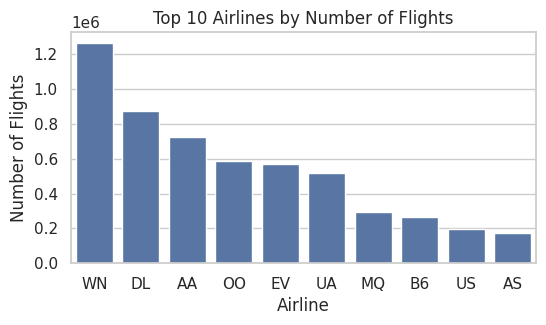

In [ ]:
# Count flights by airline -Top10
top_airlines = df['AIRLINE'].value_counts().head(10)

# Print explanation
print("Observation:")
print("The following airlines operate the highest number of flights.")
print("Top airline:", top_airlines.idxmax())
print("Number of flights:", top_airlines.max())
print("\n")

# Plot
plt.figure(figsize=(6,3))
sns.barplot(x=top_airlines.index, y=top_airlines.values)

plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.savefig("top airlines.png", bbox_inches="tight")
plt.show()

OBSERVATION
Most frequent flight route: SFO - LAX
Flights on that route: 13744
These routes experience the highest traffic.



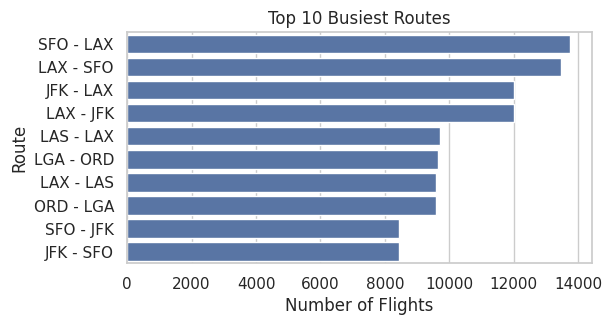

In [ ]:
# Top 10 Busiest Routes
top_routes = df['ROUTE'].value_counts().head(10)

print("OBSERVATION")
print("Most frequent flight route:", top_routes.idxmax())
print("Flights on that route:", top_routes.max())
print("These routes experience the highest traffic.\n")

plt.figure(figsize=(6,3))
sns.barplot(x=top_routes.values, y=top_routes.index)

plt.title("Top 10 Busiest Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.savefig("top routes.png", bbox_inches="tight")
plt.show()

OBSERVATION
Month with highest flights: 7
Flights in that month: 520718
Month with lowest flights: 2
Flight activity varies depending on seasonal demand.



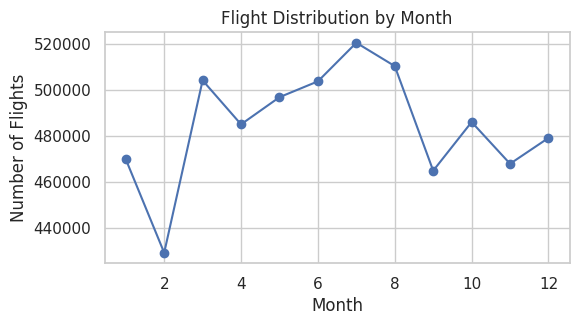

In [ ]:
# Flights by Month
monthly_flights = df.groupby("MONTH").size()

print("OBSERVATION")
print("Month with highest flights:", monthly_flights.idxmax())
print("Flights in that month:", monthly_flights.max())
print("Month with lowest flights:", monthly_flights.idxmin())
print("Flight activity varies depending on seasonal demand.\n")

plt.figure(figsize=(6,3))
monthly_flights.plot(marker='o')

plt.title("Flight Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.savefig("flight month.png", bbox_inches="tight")
plt.show()

OBSERVATION
Day with highest number of flights: 2
Flights on that day: 195986
Some days show higher traffic than others.



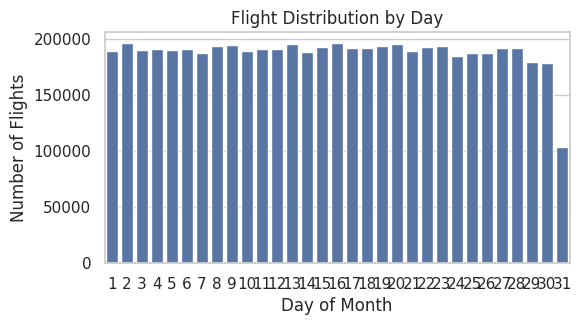

In [ ]:
# Flights Distribution by Day
day_flights = df['DAY'].value_counts().sort_index()

print("OBSERVATION")
print("Day with highest number of flights:", day_flights.idxmax())
print("Flights on that day:", day_flights.max())
print("Some days show higher traffic than others.\n")

plt.figure(figsize=(6,3))
sns.barplot(x=day_flights.index, y=day_flights.values)

plt.title("Flight Distribution by Day")
plt.xlabel("Day of Month")
plt.ylabel("Number of Flights")
plt.savefig("Distribution Per Day.png", bbox_inches="tight")
plt.show()

OBSERVATION
Peak flight hour: 17
Number of flights during that hour: 364838
This indicates the busiest departure time of the day.



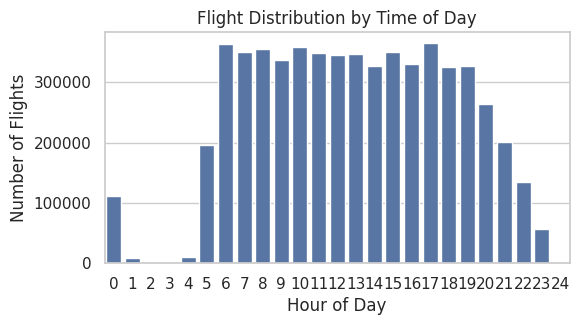

In [ ]:
# Flight Distribution per Time
# Create hour column from departure time
df['HOUR'] = (df['DEPARTURE_TIME'] // 100).fillna(0).astype(int)

# Count flights per hour
hourly_flights = df['HOUR'].value_counts().sort_index()

print("OBSERVATION")
print("Peak flight hour:", hourly_flights.idxmax())
print("Number of flights during that hour:", hourly_flights.max())
print("This indicates the busiest departure time of the day.\n")

plt.figure(figsize=(6,3))
sns.barplot(x=hourly_flights.index, y=hourly_flights.values)

plt.title("Flight Distribution by Time of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")
plt.savefig("Distribution Per Hour.png", bbox_inches="tight")
plt.show()

OBSERVATION
Airport with most departures: ATL
Number of departing flights: 346836
These airports act as major hubs in the dataset.



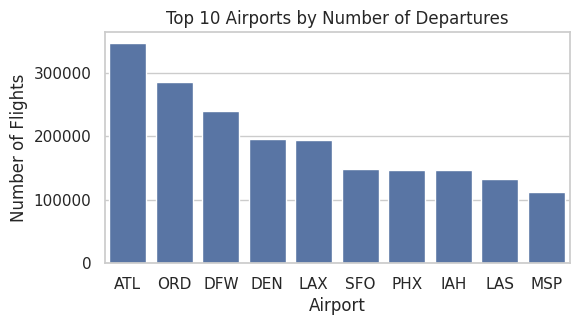

In [ ]:
# Top 10 busiest origin airports
top_airports = df['ORIGIN_AIRPORT'].value_counts().head(10)

print("OBSERVATION")
print("Airport with most departures:", top_airports.idxmax())
print("Number of departing flights:", top_airports.max())
print("These airports act as major hubs in the dataset.\n")

plt.figure(figsize=(6,3))
sns.barplot(x=top_airports.index, y=top_airports.values)

plt.title("Top 10 Airports by Number of Departures")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.savefig("Origin Airport.png", bbox_inches="tight")
plt.show()

OBSERVATION
Average delay causes by airline:

         AIRLINE_DELAY  WEATHER_DELAY  AIR_SYSTEM_DELAY
AIRLINE                                                
AA           21.139201       3.587838         13.513774
AS           15.543352       1.737294         13.487742
B6           18.150503       1.956401         16.754728
DL           22.941028       5.108335         15.076578
EV           21.651277       1.550713         15.459170

Explanation:
AIRLINE_DELAY → delays caused by airline operations
WEATHER_DELAY → delays due to weather conditions
AIR_SYSTEM_DELAY → delays from air traffic control system



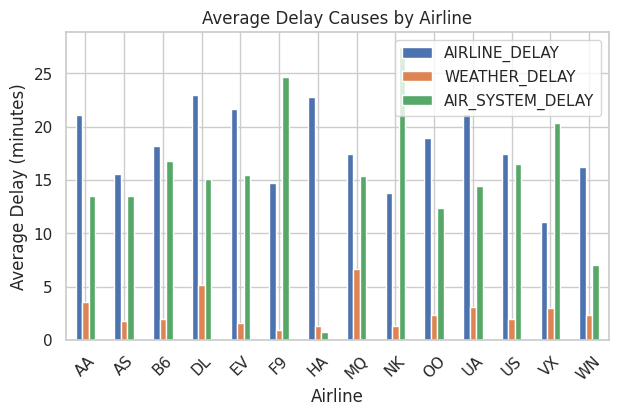

In [ ]:
#Compare Delay Causes by Airline
delay_airline = df.groupby('AIRLINE')[['AIRLINE_DELAY','WEATHER_DELAY','AIR_SYSTEM_DELAY']].mean()

print("OBSERVATION")
print("Average delay causes by airline:\n")
print(delay_airline.head())

print("\nExplanation:")
print("AIRLINE_DELAY → delays caused by airline operations")
print("WEATHER_DELAY → delays due to weather conditions")
print("AIR_SYSTEM_DELAY → delays from air traffic control system\n")

delay_airline.plot(kind='bar', figsize=(7,4))

plt.title("Average Delay Causes by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.savefig("delay causes.png", bbox_inches="tight")
plt.show()

OBSERVATION
Average delay minutes by cause:

AIRLINE_DELAY       18.969547
WEATHER_DELAY        2.915290
AIR_SYSTEM_DELAY    13.480568
dtype: float64

Major delay contributor: AIRLINE_DELAY


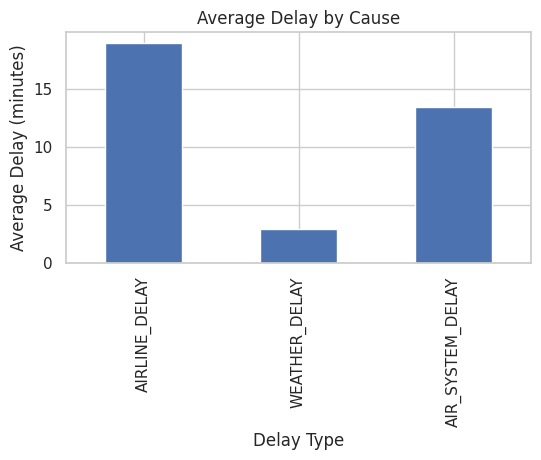

In [ ]:
#Overall Delay Cause Comparison
delay_types = df[['AIRLINE_DELAY','WEATHER_DELAY','AIR_SYSTEM_DELAY']].mean()

print("OBSERVATION")
print("Average delay minutes by cause:\n")
print(delay_types)

print("\nMajor delay contributor:", delay_types.idxmax())

plt.figure(figsize=(6,3))

delay_types.plot(kind='bar')

plt.title("Average Delay by Cause")
plt.xlabel("Delay Type")
plt.ylabel("Average Delay (minutes)")
plt.savefig("delay_cause.png", bbox_inches="tight")
plt.show()

OBSERVATION
Hour with highest delays: 2.0
Average delay during that hour: 80.43521184697656

Explanation:
Delays often increase later in the day due to accumulated disruptions.



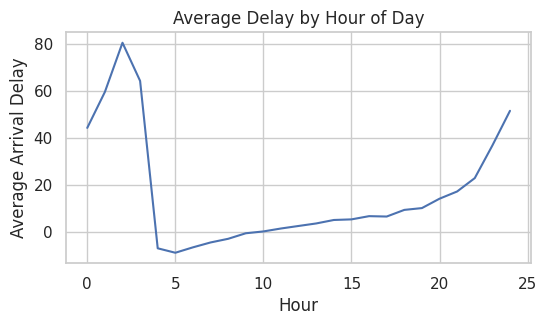

In [ ]:
#Delays by Time of Day
hour_delay = df.groupby('HOUR_AFTER')['ARRIVAL_DELAY'].mean()

print("OBSERVATION")
print("Hour with highest delays:", hour_delay.idxmax())
print("Average delay during that hour:", hour_delay.max())

print("\nExplanation:")
print("Delays often increase later in the day due to accumulated disruptions.\n")

plt.figure(figsize=(6,3))

hour_delay.plot()

plt.title("Average Delay by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Arrival Delay")
plt.savefig("delay_by_hour.png", bbox_inches="tight")
plt.show()

OBSERVATION
Airports with highest average delays:

ORIGIN_AIRPORT
ILG    22.860000
GST    21.480519
PPG    21.299065
STC    18.144578
BPT    15.025694
ASE    14.192027
OTH    13.760000
MVY    12.980488
EGE    11.971797
TTN    11.740283
Name: ARRIVAL_DELAY, dtype: float64

Explanation:
These airports experience higher average delays due to congestion, weather, or operational issues.



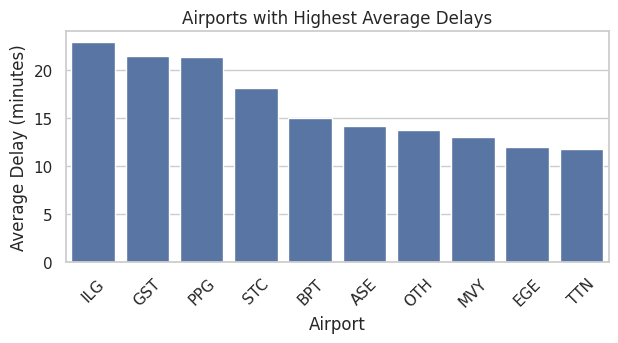

In [8]:
#Delays by Airport
df = df[df['ORIGIN_AIRPORT'].str.len() == 3]
airport_delay = df.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean().sort_values(ascending=False).head(10)

print("OBSERVATION")
print("Airports with highest average delays:\n")
print(airport_delay)

print("\nExplanation:")
print("These airports experience higher average delays due to congestion, weather, or operational issues.\n")

plt.figure(figsize=(7,3))

sns.barplot(x=airport_delay.index, y=airport_delay.values)

plt.title("Airports with Highest Average Delays")
plt.xlabel("Airport")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.savefig("delay_by_airline.png", bbox_inches="tight")
plt.show()